## Pertanyaan Bisnis

- ***Pertanyaan 1***

    Seberapa besar Fraud Rate di Negara Tujuan TKW?
- ***Pertanyaan 2***

    Berapa rata-rata perbedaan gaji antara Salary Fraud vs Legitimate? Apakah lowongan palsu menawarkan gaji lebih tinggi?
- ***Pertanyaan 3***

    Fitur apa yang paling berpengaruh dalam mendeteksi lowongan palsu?
- ***Pertanyaan 4***

    Pola pekerjaan & tipe employment yang sering menjadi target lowongan palsu?
- ***Pertanyaan 5***

    Performa model setelah tuning vs baseline?

## Import Packages/Library

In [1]:
# Import library yang dibutuhkan
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_auc_score, roc_curve, mean_absolute_error, mean_squared_error, r2_score)
from xgboost import XGBClassifier, XGBRegressor
import joblib
from IPython.display import clear_output

# Konfigurasi
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})
DATA_DIR = os.path.join(os.getcwd(), 'data')

## Data Wrangling

### Gathering Data

In [2]:
# Membaca dataset
df1 = pd.read_csv(os.path.join(DATA_DIR, 'fake_job_postings.csv'))

# Menampilkan 5 baris pertama
df1.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [3]:
# Total semua dataset
print(f"Dataset 1: {df1.shape[0]} baris, {df1.shape[1]} kolom")

Dataset 1: 17880 baris, 18 kolom


**Insight**

(bang arsyandi)

## Assessing Data

In [4]:
# Melakukan pengecekan Missing Value
print(f"Shape: {df1.shape} | Duplikasi: {df1.duplicated().sum()}")
missing = df1.isnull().sum()
missing_pct = (missing / len(df1) * 100).round(2)
mv = pd.DataFrame({'Jumlah': missing, 'Persen(%)': missing_pct})
print(mv[mv['Jumlah'] > 0].to_string() if mv[mv['Jumlah'] > 0].shape[0] > 0
      else "  Tidak ada missing values")
print(f"\nDataset 1: {df1['fraudulent'].value_counts().to_dict()}")

Shape: (17880, 18) | Duplikasi: 0
                     Jumlah  Persen(%)
location                346       1.94
department            11547      64.58
salary_range          15012      83.96
company_profile        3308      18.50
description               1       0.01
requirements           2696      15.08
benefits               7212      40.34
employment_type        3471      19.41
required_experience    7050      39.43
required_education     8105      45.33
industry               4903      27.42
function               6455      36.10

Dataset 1: {0: 17014, 1: 866}


**Insight**

(bang arsyandi)

## Cleaning Data

In [5]:
# Cek Perubahan
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [6]:
# Fungsi parsing salary
def parse_salary(s):
    if pd.isna(s):
        return np.nan, np.nan
    s = str(s).strip()
    if s.lower() in ['not disclosed', '', 'nan']:
        return np.nan, np.nan
    s = s.replace('$', '').replace(',', '')
    if 'k' in s.lower():
        parts = re.findall(r'([\d.]+)\s*k', s, re.IGNORECASE)
        if len(parts) >= 2:
            return float(parts[0]) * 1000, float(parts[1]) * 1000
    parts = re.findall(r'[\d.]+', s)
    if len(parts) >= 2:
        mn, mx = float(parts[0]), float(parts[1])
        if mn < 500 and mx < 500:
            mn, mx = mn * 2080, mx * 2080
        return mn, mx
    return np.nan, np.nan

COUNTRY_MAP = {
    'US': 'United States', 'GB': 'United Kingdom', 'UK': 'United Kingdom',
    'DE': 'Germany', 'CA': 'Canada', 'AU': 'Australia', 'IN': 'India',
    'NZ': 'New Zealand', 'SG': 'Singapore', 'MY': 'Malaysia',
    'HK': 'Hong Kong', 'AE': 'UAE', 'SA': 'Saudi Arabia', 'JP': 'Japan',
    'KR': 'South Korea', 'TW': 'Taiwan', 'FR': 'France', 'IE': 'Ireland',
    'NL': 'Netherlands', 'CH': 'Switzerland', 'IT': 'Italy', 'ES': 'Spain',
    'SE': 'Sweden', 'PL': 'Poland', 'IL': 'Israel', 'PH': 'Philippines',
    'TH': 'Thailand', 'ID': 'Indonesia', 'BR': 'Brazil', 'ZA': 'South Africa',
    'NG': 'Nigeria', 'QA': 'Qatar', 'KW': 'Kuwait', 'BH': 'Bahrain',
    'JO': 'Jordan', 'CN': 'China', 'BN': 'Brunei', 'TR': 'Turkey',
    'RU': 'Russia', 'RO': 'Romania', 'GR': 'Greece', 'BE': 'Belgium',
    'AT': 'Austria', 'NO': 'Norway', 'DK': 'Denmark', 'FI': 'Finland',
    'PK': 'Pakistan', 'BD': 'Bangladesh', 'EG': 'Egypt', 'OM': 'Oman',
    'LB': 'Lebanon', 'MX': 'Mexico', 'AR': 'Argentina', 'CO': 'Colombia',
    'CL': 'Chile', 'HR': 'Croatia', 'HU': 'Hungary', 'CZ': 'Czech Republic',
    'PT': 'Portugal', 'UA': 'Ukraine', 'RS': 'Serbia', 'BG': 'Bulgaria',
    'LK': 'Sri Lanka', 'MM': 'Myanmar', 'VN': 'Vietnam',
}

CITY_MAP = {
    'toronto': 'Canada', 'london': 'United Kingdom', 'berlin': 'Germany',
    'new york': 'United States', 'paris': 'France', 'sydney': 'Australia',
    'tokyo': 'Japan', 'singapore': 'Singapore', 'dubai': 'UAE',
    'hong kong': 'Hong Kong', 'kuala lumpur': 'Malaysia',
    'riyadh': 'Saudi Arabia', 'taipei': 'Taiwan', 'seoul': 'South Korea',
}

def get_country(loc):
    if pd.isna(loc):
        return 'Unknown'
    loc = str(loc).strip()
    code = loc.split(',')[0].strip()
    return COUNTRY_MAP.get(code, code)

# Cleaning Dataset
df = df1[['title', 'location', 'salary_range', 'description', 'requirements',
          'company_profile', 'employment_type', 'industry', 'benefits',
          'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']].copy()
df['country'] = df['location'].apply(get_country)
p = df['salary_range'].apply(parse_salary)
df['salary_min'] = p.apply(lambda x: x[0])
df['salary_max'] = p.apply(lambda x: x[1])

# Handle missing values
for col in ['description', 'requirements', 'company_profile', 'benefits']:
    df[col] = df[col].fillna('')
for col in ['employment_type', 'industry', 'title']:
    df[col] = df[col].fillna('Unknown')
for col in ['telecommuting', 'has_company_logo', 'has_questions']:
    df[col] = df[col].fillna(0).astype(int)

before = len(df)
df.drop_duplicates(subset=['title', 'description', 'location'], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Duplikat dihapus: {before - len(df)} | Final: {df.shape}")
print(f"Label distribusi: {df['fraudulent'].value_counts().to_dict()}")

Duplikat dihapus: 512 | Final: (17368, 16)
Label distribusi: {0: 16552, 1: 816}


**Insight**

(bang arsyandi)

## Feature Engineering

In [7]:
df['salary_mid'] = (df['salary_min'] + df['salary_max']) / 2
df['salary_spread'] = df['salary_max'] - df['salary_min']
df['salary_spread_ratio'] = np.where(
    df['salary_mid'] > 0, df['salary_spread'] / df['salary_mid'], np.nan)
df['has_salary'] = df['salary_min'].notna().astype(int)

df['title_length'] = df['title'].str.len()
df['desc_length'] = df['description'].str.len()
df['req_length'] = df['requirements'].str.len()
df['has_company_profile'] = (df['company_profile'].str.len() > 0).astype(int)

scam_kw = ['earn money', 'work from home', 'no experience', 'immediate', 'urgent',
           'act now', 'click here', 'guaranteed', 'contact now',
           'immediate hiring', 'no degree required']
df['scam_keyword_count'] = df['description'].apply(
    lambda x: sum(1 for kw in scam_kw if kw in str(x).lower()) if pd.notna(x) else 0)
df['has_email_in_desc'] = df['description'].str.contains(
    r'[\w.-]+@[\w.-]+\.\w+', regex=True, na=False).astype(int)
df['exclamation_count'] = df['description'].str.count('!').fillna(0)

print(f"Shape setelah FE dasar: {df.shape}")
print("\nNote: Target encoding & imputasi akan dilakukan SETELAH split (di create_features).")

Shape setelah FE dasar: (17368, 27)

Note: Target encoding & imputasi akan dilakukan SETELAH split (di create_features).


**Insight**

(bang arsyandi)

## Modeling

In [8]:
# Label Encoding
le_country = LabelEncoder()
le_emp     = LabelEncoder()
le_ind     = LabelEncoder()
df['country_enc']  = le_country.fit_transform(df['country'].astype(str))
df['emp_type_enc'] = le_emp.fit_transform(df['employment_type'].astype(str))
df['industry_enc'] = le_ind.fit_transform(df['industry'].astype(str))

# Train-Test Split SEBELUM Target Encoding
X_base = df.drop(columns=['fraudulent'])
y = df['fraudulent']
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train_raw)} | Test: {len(X_test_raw)} | Fraud rate: {y_train.mean()*100:.1f}%")

def create_features(X_data, X_train_ref, y_train_ref):
    X_out = X_data.copy()

    # 1. Target Encoding: Country Fraud Rate
    cf_rate = y_train_ref.groupby(X_train_ref['country']).mean().to_dict()
    global_cf_rate = y_train_ref.mean()
    X_out['country_fraud_rate'] = X_out['country'].map(cf_rate).fillna(global_cf_rate)
    X_out['country_safety_score'] = 1 - X_out['country_fraud_rate']

    # 2. Target Encoding: Avg Salary Legitimate
    legit_mask = (y_train_ref == 0) & X_train_ref['salary_mid'].notna()
    legit_train = X_train_ref[legit_mask]
    cs_avg = legit_train.groupby('country')['salary_mid'].mean().to_dict()
    global_cs_avg = legit_train['salary_mid'].mean() if len(legit_train) > 0 else 0

    X_out['country_avg_salary'] = X_out['country'].map(cs_avg).fillna(global_cs_avg)
    X_out['salary_vs_country_avg'] = np.where(
        X_out['salary_mid'].notna() & (X_out['country_avg_salary'] > 0),
        X_out['salary_mid'] / X_out['country_avg_salary'], np.nan)

    # 3. Imputasi Missing Value
    base_impute = ['salary_mid', 'salary_spread', 'salary_spread_ratio']
    medians = X_train_ref[base_impute].median()
    X_out[base_impute] = X_out[base_impute].fillna(medians)
    X_out['country_avg_salary'] = X_out['country_avg_salary'].fillna(global_cs_avg)
    X_out['salary_vs_country_avg'] = X_out['salary_vs_country_avg'].fillna(0)

    FEATURES_LIST = [
        'salary_mid', 'salary_spread', 'salary_spread_ratio', 'has_salary',
        'title_length', 'desc_length', 'req_length', 'has_company_profile',
        'scam_keyword_count', 'has_email_in_desc', 'exclamation_count',
        'country_fraud_rate', 'country_safety_score', 'country_avg_salary',
        'salary_vs_country_avg', 'telecommuting', 'has_company_logo',
        'has_questions', 'country_enc', 'emp_type_enc', 'industry_enc'
    ]
    return X_out[FEATURES_LIST].fillna(0), medians, cf_rate, cs_avg


# Transform Data
X_train, medians_train, cf_rate_train, cs_avg_train = create_features(
    X_train_raw, X_train_raw, y_train)
X_test, _, _, _ = create_features(X_test_raw, X_train_raw, y_train)

FEATURES = X_train.columns.tolist()
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos:.2f}")

# Baseline
rf_base = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)

xgb_base = XGBClassifier(
    n_estimators=100, scale_pos_weight=scale_pos,
    random_state=42, eval_metric='logloss')
xgb_base.fit(X_train, y_train)

Train: 13894 | Test: 3474 | Fraud rate: 4.7%
scale_pos_weight: 20.28


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [9]:
# Tuning RF
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None],
     'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]},
    cv=3, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

In [10]:
# Tuning XGBoost
xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos, random_state=42, eval_metric='logloss'),
    {'n_estimators': [100, 200, 300], 'max_depth': [3, 6, 10],
     'learning_rate': [0.01, 0.1, 0.2], 'subsample': [0.8, 1.0]},
    cv=3, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

In [11]:
# Evaluasi semua model
models = {
    'RF Baseline': rf_base, 'XGB Baseline': xgb_base,
    'RF Tuned': best_rf, 'XGB Tuned': best_xgb
}

results = []
for name, m in models.items():
    yp = m.predict(X_test)
    ypr = m.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, yp) * 100,
        'F1': f1_score(y_test, yp) * 100,
        'AUC': roc_auc_score(y_test, ypr) * 100
    })
results_df = pd.DataFrame(results).round(2)
print(results_df.to_string(index=False))

best_model_name = results_df.loc[results_df['F1'].idxmax(), 'Model']
best_clf = models[best_model_name]
print(f"\nModel terbaik (berdasarkan F1): {best_model_name}")
print(classification_report(y_test, best_clf.predict(X_test),
                            target_names=['Legitimate', 'Fraudulent']))

       Model  Accuracy    F1   AUC
 RF Baseline     97.58 67.94 95.31
XGB Baseline     96.83 68.57 95.66
    RF Tuned     97.35 69.33 94.86
   XGB Tuned     97.44 71.92 95.04

Model terbaik (berdasarkan F1): XGB Tuned
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3311
  Fraudulent       0.74      0.70      0.72       163

    accuracy                           0.97      3474
   macro avg       0.86      0.84      0.85      3474
weighted avg       0.97      0.97      0.97      3474



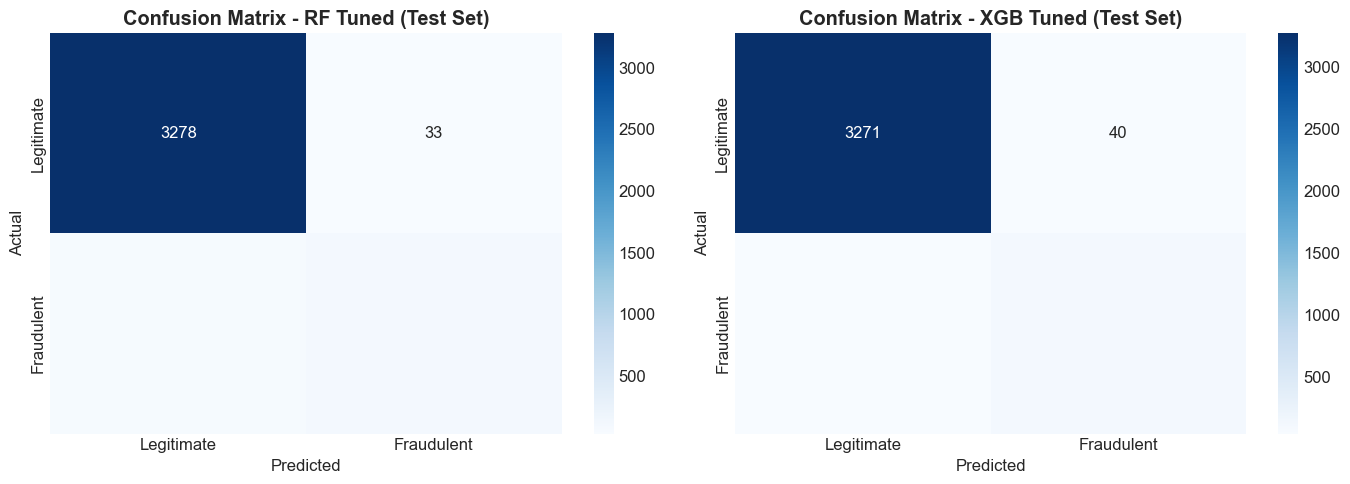

In [12]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, m, t in zip(axes, [best_rf, best_xgb], ['RF Tuned', 'XGB Tuned']):
    cm = confusion_matrix(y_test, m.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Fraudulent'],
                yticklabels=['Legitimate', 'Fraudulent'])
    ax.set_title(f'Confusion Matrix - {t} (Test Set)', fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

**Insight**

(bang arsyandi)

## Visualization & Exploratory Analysis

In [13]:
# Aggregate data
cs_eda = df.groupby('country').agg(
    total=('fraudulent', 'count'), fraud=('fraudulent', 'sum')
).reset_index()
cs_eda['fraud_rate'] = (cs_eda['fraud'] / cs_eda['total'] * 100).round(2)
cs_eda = cs_eda[cs_eda['total'] >= 10].sort_values('fraud_rate', ascending=False)

TKW = ['Saudi Arabia', 'Malaysia', 'Singapore', 'Hong Kong', 'Taiwan', 'UAE',
       'South Korea', 'Japan', 'Brunei', 'Kuwait', 'Qatar', 'Jordan', 'China']
tkw_stats = cs_eda[cs_eda['country'].isin(TKW)].sort_values('fraud_rate', ascending=False)

### Pertanyaan 1:

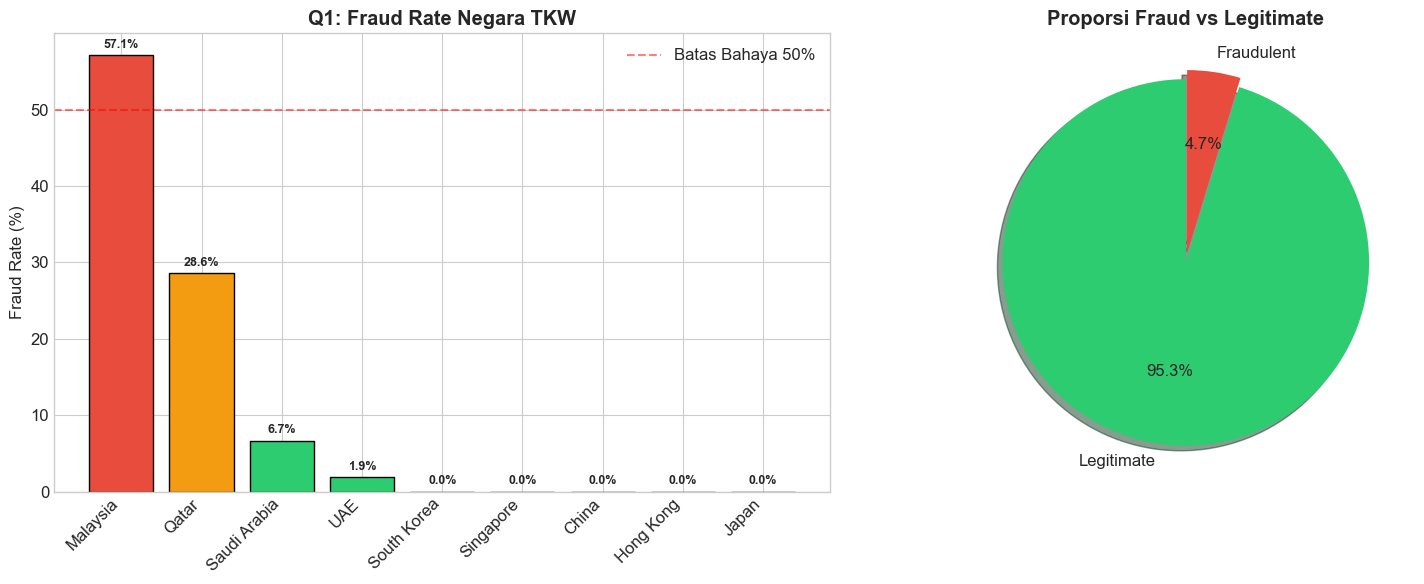

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_q1 = ['#e74c3c' if r > 50 else '#f39c12' if r > 25 else '#2ecc71'
             for r in tkw_stats['fraud_rate']]
axes[0].bar(tkw_stats['country'], tkw_stats['fraud_rate'],
            color=colors_q1, edgecolor='black')
axes[0].set_ylabel('Fraud Rate (%)'); axes[0].set_title('Q1: Fraud Rate Negara TKW', fontweight='bold')
axes[0].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Batas Bahaya 50%')
axes[0].legend()
plt.sca(axes[0]); plt.xticks(rotation=45, ha='right')
for i, (_, row) in enumerate(tkw_stats.iterrows()):
    axes[0].text(i, row['fraud_rate'] + 1, f"{row['fraud_rate']:.1f}%",
                 ha='center', fontsize=9, fontweight='bold')
fraud_counts = df['fraudulent'].value_counts()
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraudulent'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.05), shadow=True)
axes[1].set_title('Proporsi Fraud vs Legitimate', fontweight='bold')
plt.tight_layout(); plt.show()

**Insight**

(bang arsyandi)

### Pertanyaan 2:

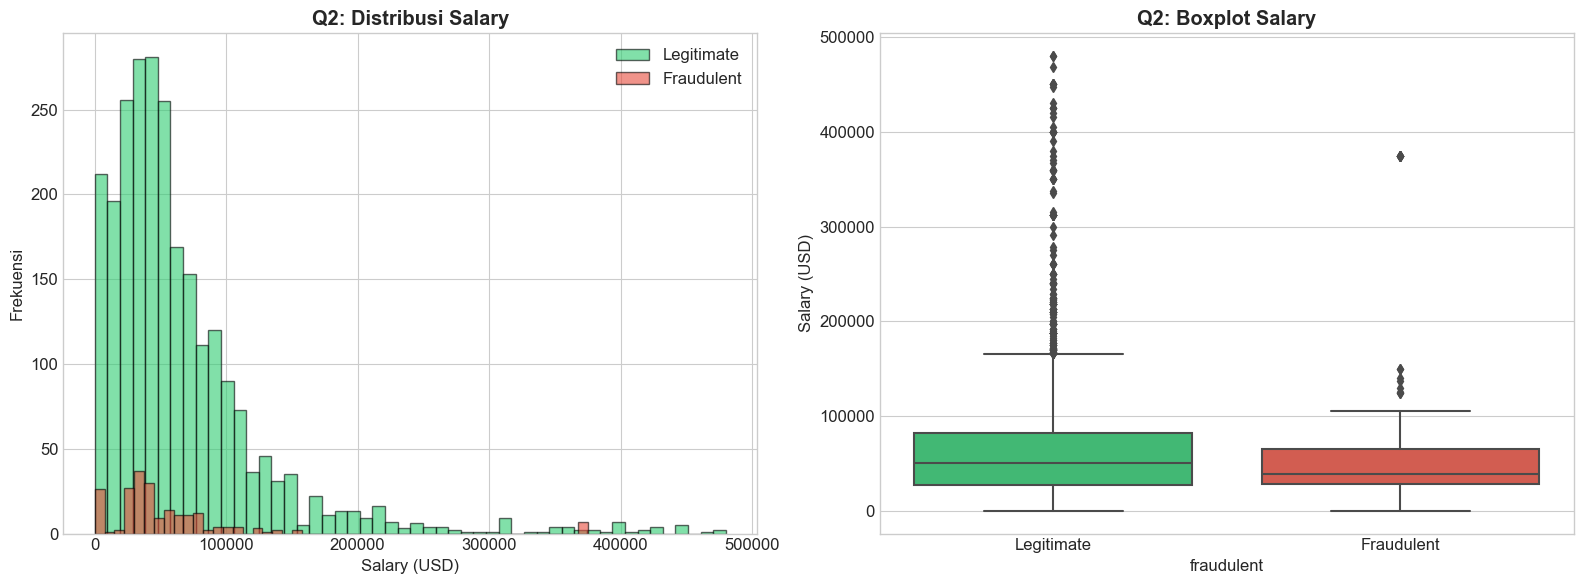

In [15]:
df_sal = df[df['salary_mid'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    sub = df_sal[(df_sal['fraudulent'] == label) & (df_sal['salary_mid'] < 500000)]['salary_mid']
    lbl = 'Legitimate' if label == 0 else 'Fraudulent'
    axes[0].hist(sub, bins=50, alpha=0.6, label=lbl, color=color, edgecolor='black')
axes[0].set_title('Q2: Distribusi Salary', fontweight='bold')
axes[0].set_xlabel('Salary (USD)'); axes[0].set_ylabel('Frekuensi'); axes[0].legend()
sns.boxplot(data=df_sal[df_sal['salary_mid'] < 500000], x='fraudulent', y='salary_mid',
            ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_xticklabels(['Legitimate', 'Fraudulent'])
axes[1].set_title('Q2: Boxplot Salary', fontweight='bold'); axes[1].set_ylabel('Salary (USD)')
plt.tight_layout(); plt.show()

**Insight**

(bang arsyandi)

### Pertanyaan 3:

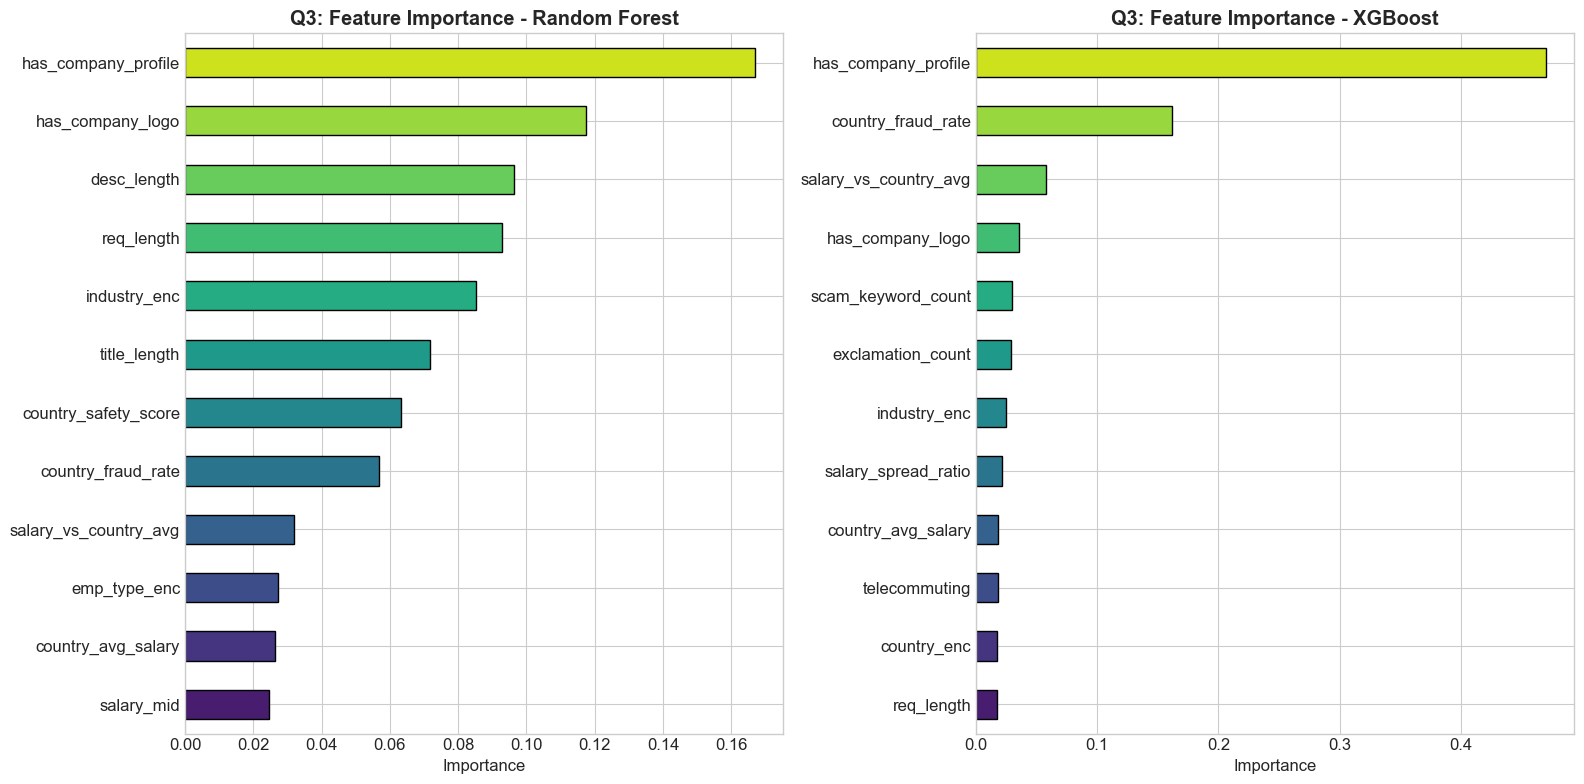

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, model, title in zip(axes, [best_rf, best_xgb], ['Random Forest', 'XGBoost']):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    imp.tail(12).plot(kind='barh', ax=ax,
                      color=sns.color_palette('viridis', 12), edgecolor='black')
    ax.set_title(f'Q3: Feature Importance - {title}', fontweight='bold')
    ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

**Insight**

(bang arsyandi)

### Pertanyaan 4:

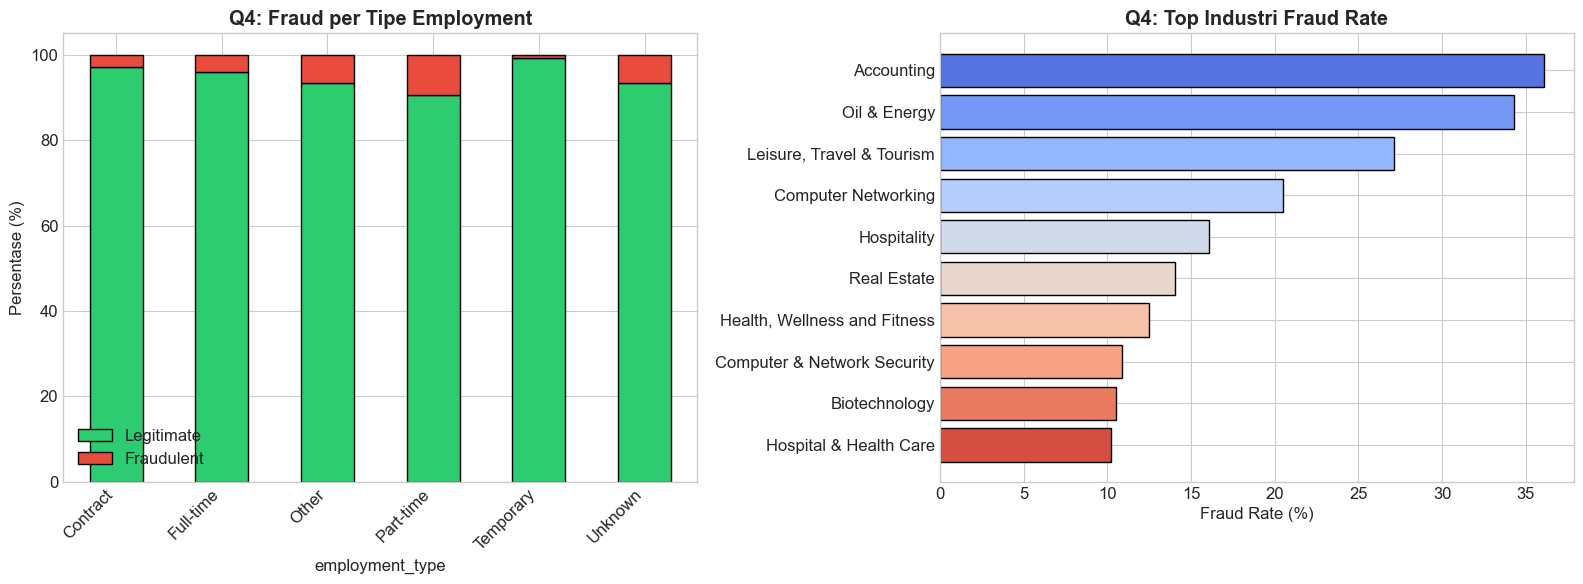

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
emp = df.groupby(['employment_type', 'fraudulent']).size().unstack(fill_value=0)
emp_pct = emp.div(emp.sum(axis=1), axis=0) * 100
emp_pct.plot(kind='bar', stacked=True, ax=axes[0],
             color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Q4: Fraud per Tipe Employment', fontweight='bold')
axes[0].set_ylabel('Persentase (%)'); axes[0].legend(['Legitimate', 'Fraudulent'])
plt.sca(axes[0]); plt.xticks(rotation=45, ha='right')
ind_eda = df.groupby('industry').agg(
    total=('fraudulent', 'count'), fraud=('fraudulent', 'sum')
).reset_index()
ind_eda['fraud_rate'] = (ind_eda['fraud'] / ind_eda['total'] * 100).round(2)
ind_eda = ind_eda[ind_eda['total'] >= 20].sort_values('fraud_rate', ascending=False).head(10)
axes[1].barh(ind_eda['industry'], ind_eda['fraud_rate'],
             color=sns.color_palette('coolwarm', len(ind_eda)), edgecolor='black')
axes[1].set_xlabel('Fraud Rate (%)'); axes[1].set_title('Q4: Top Industri Fraud Rate', fontweight='bold')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

**Insight**

(bang arsyandi)

### Pertanyaan 5:

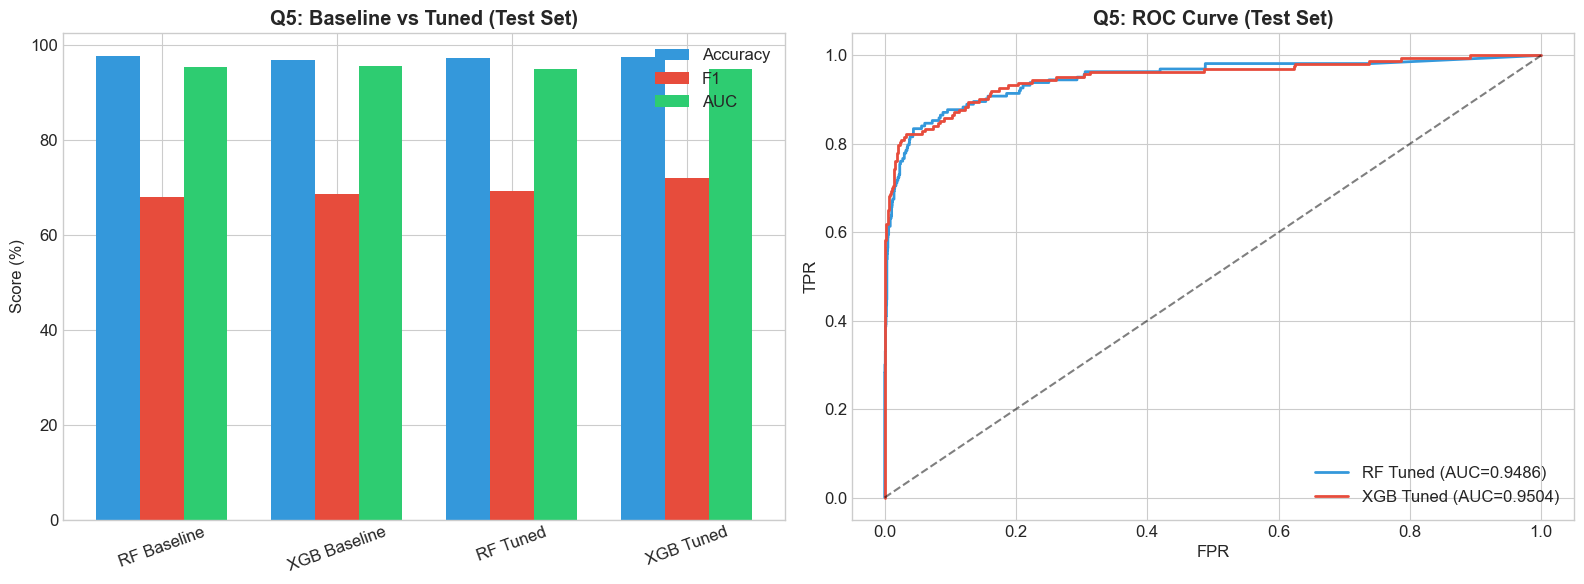

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x_pos = np.arange(len(results_df)); w = 0.25
axes[0].bar(x_pos - w, results_df['Accuracy'], w, label='Accuracy', color='#3498db')
axes[0].bar(x_pos,     results_df['F1'],       w, label='F1',       color='#e74c3c')
axes[0].bar(x_pos + w, results_df['AUC'],      w, label='AUC',      color='#2ecc71')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(results_df['Model'], rotation=20)
axes[0].set_ylabel('Score (%)'); axes[0].legend()
axes[0].set_title('Q5: Baseline vs Tuned (Test Set)', fontweight='bold')

for m, name, color in [(best_rf, 'RF Tuned', '#3498db'), (best_xgb, 'XGB Tuned', '#e74c3c')]:
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:, 1])
    auc_val = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', color=color, linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Q5: ROC Curve (Test Set)', fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.show()

**Insight**

(bang arsyandi)

## Salary Prediction

In [19]:
SAL_FEAT = ['country_enc', 'emp_type_enc', 'industry_enc',
            'title_length', 'desc_length', 'telecommuting']

sal_mask_train = (
    (y_train == 0) &
    X_train_raw['salary_mid'].notna() &
    (X_train_raw['salary_mid'] > 0) &
    (X_train_raw['salary_mid'] < 500000)
)
sal_mask_test = (
    (y_test == 0) &
    X_test_raw['salary_mid'].notna() &
    (X_test_raw['salary_mid'] > 0) &
    (X_test_raw['salary_mid'] < 500000)
)

Xs_tr = X_train_raw.loc[sal_mask_train, SAL_FEAT].fillna(0)
ys_tr = X_train_raw.loc[sal_mask_train, 'salary_mid']
Xs_te = X_test_raw.loc[sal_mask_test, SAL_FEAT].fillna(0)
ys_te = X_test_raw.loc[sal_mask_test, 'salary_mid']

rf_reg  = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
xgb_reg = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
rf_reg.fit(Xs_tr, ys_tr)
xgb_reg.fit(Xs_tr, ys_tr)

r2_rf  = r2_score(ys_te, rf_reg.predict(Xs_te))
r2_xgb = r2_score(ys_te, xgb_reg.predict(Xs_te))

print(f"RF  - MAE: ${mean_absolute_error(ys_te, rf_reg.predict(Xs_te)):,.0f} | R2: {r2_rf*100:.2f}%")
print(f"XGB - MAE: ${mean_absolute_error(ys_te, xgb_reg.predict(Xs_te)):,.0f} | R2: {r2_xgb*100:.2f}%")

best_sal = rf_reg if r2_rf >= r2_xgb else xgb_reg
sal_name = "RF" if r2_rf >= r2_xgb else "XGB"
print(f"Model salary terpilih: {sal_name}")

RF  - MAE: $34,077 | R2: 37.63%
XGB - MAE: $34,085 | R2: 39.18%
Model salary terpilih: XGB


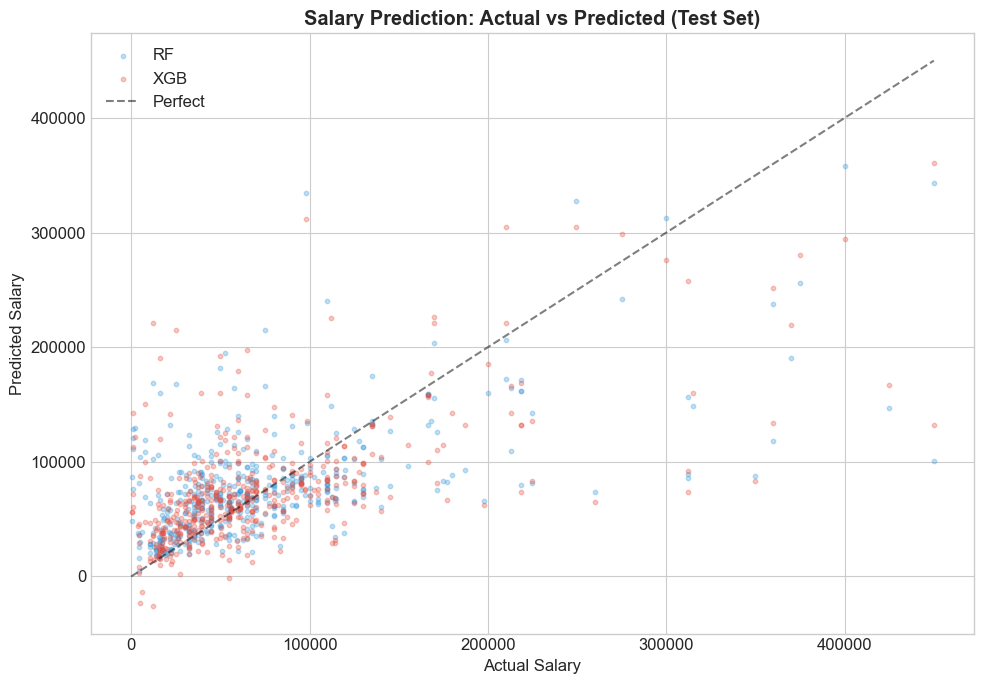

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(ys_te, rf_reg.predict(Xs_te),  alpha=0.3, s=10, color='#3498db', label='RF')
ax.scatter(ys_te, xgb_reg.predict(Xs_te), alpha=0.3, s=10, color='#e74c3c', label='XGB')
ax.plot([0, ys_te.max()], [0, ys_te.max()], 'k--', alpha=0.5, label='Perfect')
ax.set_xlabel('Actual Salary'); ax.set_ylabel('Predicted Salary')
ax.set_title('Salary Prediction: Actual vs Predicted (Test Set)', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# Tambahkan expected salary ke df
df['expected_salary']     = best_sal.predict(df[SAL_FEAT].fillna(0))
df['salary_deviation']    = np.where(
    df['expected_salary'] > 0,
    (df['salary_mid'] - df['expected_salary']) / df['expected_salary'], 0)
df['salary_is_fair']      = (df['salary_deviation'].abs() <= 0.3).astype(int)

**Insight**

(bang arsyandi)

## A/B Testing

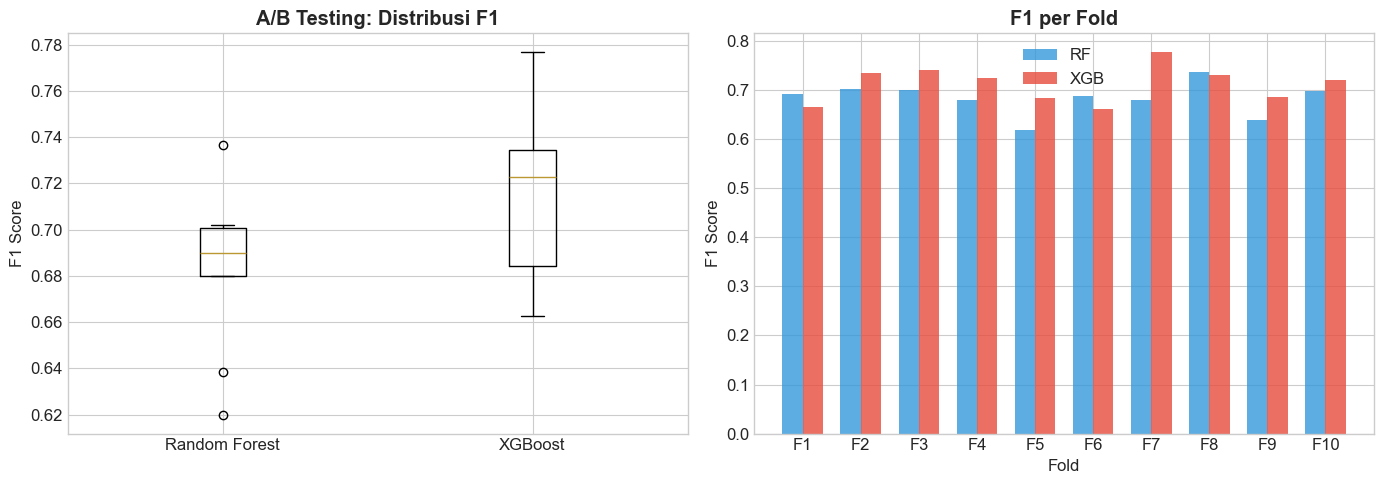

In [21]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
rf_scores  = []
xgb_scores = []

X_full_base = df.drop(columns=['fraudulent'])
y_full = df['fraudulent']

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_full_base, y_full)):
    X_tr_fold = X_full_base.iloc[train_idx]
    y_tr_fold = y_full.iloc[train_idx]
    X_te_fold = X_full_base.iloc[test_idx]
    y_te_fold = y_full.iloc[test_idx]

    X_tr_clean, _, _, _ = create_features(X_tr_fold, X_tr_fold, y_tr_fold)
    X_te_clean, _, _, _ = create_features(X_te_fold, X_tr_fold, y_tr_fold)

    best_rf.fit(X_tr_clean, y_tr_fold)
    rf_scores.append(f1_score(y_te_fold, best_rf.predict(X_te_clean)))

    best_xgb.fit(X_tr_clean, y_tr_fold)
    xgb_scores.append(f1_score(y_te_fold, best_xgb.predict(X_te_clean)))
    print(f"  Fold {fold_i+1:2d} | RF={rf_scores[-1]:.4f} | XGB={xgb_scores[-1]:.4f}")
    clear_output(wait=True)

# Refit pada full train set setelah CV
best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)

rf_scores  = np.array(rf_scores)
xgb_scores = np.array(xgb_scores)

t_stat, p_val = stats.ttest_rel(rf_scores, xgb_scores)
diff = rf_scores - xgb_scores
cohens_d = diff.mean() / diff.std() if diff.std() > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot([rf_scores, xgb_scores], labels=['Random Forest', 'XGBoost'])
axes[0].set_ylabel('F1 Score'); axes[0].set_title('A/B Testing: Distribusi F1', fontweight='bold')
x = np.arange(10); w_ab = 0.35
axes[1].bar(x - w_ab/2, rf_scores,  w_ab, label='RF',  color='#3498db', alpha=0.8)
axes[1].bar(x + w_ab/2, xgb_scores, w_ab, label='XGB', color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 per Fold', fontweight='bold'); axes[1].legend()
axes[1].set_xticks(x); axes[1].set_xticklabels([f'F{i+1}' for i in range(10)])
plt.tight_layout(); plt.show()

**Insight**

(bang arsyandi)

## Save Data & Export Model

In [22]:
X_full_clean, _, _, _ = create_features(
    df.drop(columns=['fraudulent']), X_train_raw, y_train)

# Final classifier
final_clf = (
    best_xgb
    if f1_score(y_test, best_xgb.predict(X_test)) >= f1_score(y_test, best_rf.predict(X_test))
    else best_rf
)

# Masukkan fitur bersih ke df
for col in FEATURES:
    df[col] = X_full_clean[col]

df['fraud_prediction']    = final_clf.predict(X_full_clean)
df['fraud_probability']   = final_clf.predict_proba(X_full_clean)[:, 1]
df['expected_salary_min'] = (df['expected_salary'] * 0.85).round(2)
df['expected_salary_max'] = (df['expected_salary'] * 1.15).round(2)

def risk_level(r):
    score = 0
    if r['fraud_probability'] > 0.7:   score += 3
    elif r['fraud_probability'] > 0.4: score += 2
    else:                               score += 1
    if r['country_safety_score'] < 0.5:   score += 2
    elif r['country_safety_score'] < 0.7: score += 1
    if r['salary_is_fair'] == 0: score += 1
    if score >= 5:   return 'SANGAT BERBAHAYA'
    elif score >= 3: return 'BERBAHAYA'
    elif score >= 2: return 'WASPADA'
    return 'AMAN'

df['risk_level'] = df.apply(risk_level, axis=1)

# Save CSV
out_cols = [
    'title', 'location', 'country', 'salary_range', 'salary_min', 'salary_max', 'salary_mid',
    'description', 'requirements', 'company_profile', 'employment_type', 'industry', 'benefits',
    'fraudulent', 'salary_spread', 'salary_spread_ratio', 'has_salary', 'title_length',
    'desc_length', 'req_length', 'has_company_profile', 'scam_keyword_count',
    'has_email_in_desc', 'exclamation_count', 'country_avg_salary', 'salary_vs_country_avg',
    'country_fraud_rate', 'country_safety_score', 'telecommuting', 'has_company_logo',
    'has_questions', 'expected_salary', 'expected_salary_min', 'expected_salary_max',
    'salary_deviation', 'salary_is_fair', 'fraud_prediction', 'fraud_probability',
    'risk_level'
]

os.makedirs(os.path.join(os.getcwd(), 'dashboard'), exist_ok=True)
out_path = os.path.join(os.getcwd(), 'dashboard', 'main_data.csv')
df[out_cols].to_csv(out_path, index=False)

# Export Models
model_dir = os.path.join(os.getcwd(), 'model')
os.makedirs(model_dir, exist_ok=True)

joblib.dump(final_clf,     os.path.join(model_dir, 'fraud_detector.joblib'))
joblib.dump(best_sal,      os.path.join(model_dir, 'salary_predictor.joblib'))
joblib.dump({'country': le_country, 'employment_type': le_emp, 'industry': le_ind},
            os.path.join(model_dir, 'label_encoders.joblib'))
joblib.dump(FEATURES,      os.path.join(model_dir, 'fraud_feature_cols.joblib'))
joblib.dump(SAL_FEAT,      os.path.join(model_dir, 'salary_feature_cols.joblib'))
joblib.dump(cf_rate_train, os.path.join(model_dir, 'country_fraud_rates.joblib'))
joblib.dump(cs_avg_train,  os.path.join(model_dir, 'country_salary_avg.joblib'))
joblib.dump(medians_train, os.path.join(model_dir, 'imputation_medians.joblib'))
clear_output(wait=True)